# Learning Probability Distributions with Normalizing Flows

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Companion/cc_normflows/normflows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [1]:
# !pip install deeplay  # Uncomment if using Colab/Kaggle.

Normalizing flows are generative models that learn an invertible transformation between a simple probability distribution and a more complex data distribution.

In this notebook, you'll train a normalizing flow based to learn an invertible mapping between a two-dimensional distribution and a standard Gaussian distribution.
You'll see how a sequence of invertible neural-network layers—specifically, Real-valued Non-Volume Preserving transformations (RealNVPs)—progressively transforms a simple Gaussian distribution into the complex data distribution, and how the same model maps data back into a Gaussian latent space.
Finally, you'll train the model by maximizing the likelihood of the observed data.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This companion example extends the generative-modeling sequence in <em>Deep Learning Crash Course</em>. It connects most directly to autoencoders (Chapter 4), generative adversarial networks (Chapter 9), and diffusion models (Chapter 10). Unlike those examples, the model here is explicitly invertible and provides an exact likelihood for each data point.

<strong>Deep Learning Crash Course</strong>  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)
</div>

## Understanding Normalizing Flows

Many generative models learn to produce new samples, but they do not always provide an exact probability density. A generative adversarial network can generate realistic samples, but it does not directly tell you the probability of a given input. A variational autoencoder provides a likelihood lower bound, not an exact likelihood. A diffusion model defines a gradual denoising process, but sampling typically requires many iterative steps.

Normalizing flows occupy a unique position among these models. They learn an invertible transformation between a simple latent distribution (typically a Gaussian) and the complex distribution of the training data. This allows them to both generate new samples and assign an exact probability density to every sample.


The following table summarizes the main differences.

| Model | Learns latent representation | Exact likelihood | Fast sampling | Invertible | Main idea |
|:------|:----------------------------:|:----------------:|:-------------:|:----------:|:----------|
| Autoencoder | ✓ | ✗ | ✓ | ✗ | Compress and reconstruct data |
| Variational Autoencoder (VAE) | ✓ | Approximate | ✓ | ✗ | Learn a probabilistic latent space |
| GAN | Implicit | ✗ | ✓ | ✗ | Generate samples through adversarial training |
| Diffusion Model | Implicit | Approximate | ✗ | ✗ | Gradually remove noise to generate data |
| **Normalizing Flow** | ✓ | **✓** | **✓** | **✓** | Learn an invertible mapping between a Gaussian and the data distribution |


A normalizing flow starts from a simple latent random variable, typically sampled from a standard multivariate Gaussian distribution,
$$
z \sim \mathcal{N}(0,I)
$$
and learns an invertible transformation
$$
x = f_\theta(z)
$$
that maps this latent variable $z$ to the data space $x$. Here, $\theta$ denotes the trainable parameters of the model, which are optimized during training to make the transformed distribution match the data distribution.

Because the transformation is invertible, you can also go in the opposite direction:
$$
z = f_\theta^{-1}(x)
$$
This means that the same model can both generate new samples by transforming Gaussian latent variables into the data space and map existing data back into the latent space, where their probability density can be evaluated exactly.

### Transforming Probability Densities

The key mathematical idea behind normalizing flows is the *change-of-variables formula*. It tells you how the probability density changes when you apply an invertible transformation.

To build some intuition, imagine drawing equally spaced dots on a rubber sheet.
If you stretch one region of the sheet, the dots move farther apart, so their density decreases.
If you compress another region, the dots move closer together, so their density increases.

A normalizing flow behaves in exactly the same way. As it transforms a simple Gaussian distribution into the data distribution, it continuously stretches and compresses different regions of space. To correctly describe the transformed distribution, you therefore need to account for these local changes in density.

A simple one-dimensional example illustrates this idea. Suppose your transformation simply doubles every coordinate,
$$
x = 2z
$$
Points become twice as far apart, so the probability density becomes half as large.

Conversely, if
$$
x = \frac{z}{2}
$$
the points become twice as close together, so the density doubles.

In one dimension, the stretching or compression is measured by the derivative of the transformation. In higher dimensions, the corresponding quantity is the *Jacobian determinant*, which measures how the transformation changes the volume of an infinitesimally small region around each point.

Suppose now that a data point $x$ is mapped to its latent representation
$$
z=f_\theta^{-1}(x)
$$
The probability density of the data point is then given by
$$
p_X(x)
=
p_Z(z)
\left|
\det
\frac{\partial z}{\partial x}
\right|
$$
where

- $p_X(x)$ is the probability density in the data space;

- $p_Z(z)$ is the probability density in the latent space, where we assume a simple Gaussian distribution;

- $\frac{\partial z}{\partial x}$ is the *Jacobian matrix*, which contains the partial derivatives of the transformation;

- $\left|\det \frac{\partial z}{\partial x}\right|$ is absolute value of the *determinant* of the Jacobian matrix, which measures how much the transformation locally stretches or compresses space.

### Training a Normalizing Flow

The change-of-variables formula tells you how to compute the probability density of any data point under the model. If the transformation expands a small region, the probability density decreases. If it compresses the region, the probability density increases. The determinant of the Jacobian matrix provides the correction needed to account for these geometric changes.

Unlike supervised learning, where a model learns to predict labels, a normalizing flow learns the probability distribution of the training data. The goal is therefore to assign *high probability densities* to the observed data points and lower probability densities to points that do not belong to the data distribution.

During training, each data point is first mapped from the data space to the latent space using the inverse transformation. Since the latent space follows a standard Gaussian distribution, you can easily compute how likely it is. The change-of-variables formula then corrects this probability to account for the stretching and compression introduced by the transformation, giving the probability density of the original data point.

The parameters of the neural networks defining the transformation are then adjusted so that the training data receive increasingly high probability densities. As training progresses, the learned transformation gradually reshapes the data distribution into a Gaussian distribution in the latent space.

Rather than working directly with probability densities, it is more convenient to work with their logarithms. Taking the logarithm of the change-of-variables formula gives
$$
\log p_X(x)
=
\log p_Z(z)
+
\log
\left|
\det
\frac{\partial z}{\partial x}
\right|
$$
This quantity is called the *log-likelihood*. It has a simple interpretation:

* The first term, $\log p_Z(z)$, measures how likely the transformed point is under the standard Gaussian distribution in the latent space.
* The second term, $\log\left|\det\frac{\partial z}{\partial x}\right|$, corrects this probability to account for the stretching and compression introduced by the transformation.

The objective of training is to *maximize the log-likelihood* of the training data. Since optimization algorithms are usually designed to minimize a loss function rather than maximize an objective, you instead minimize its negative,
$$
\mathcal{L}
=
-\log p_X(x)
$$
which is called the *negative log-likelihood (NLL)*. Minimizing the NLL is therefore equivalent to maximizing the log-likelihood, encouraging the model to assign high probability densities to the observed data.

Importantly, although the probability density is computed for each training sample individually, the neural-network parameters are shared by all samples. During training, the log-likelihoods of all training samples (or of a mini-batch) are added together to form a single loss. Gradient descent then adjusts the shared parameters to maximize the total likelihood, learning one transformation that best explains the entire dataset.

### Why Special Layers Are Needed

A generic neural network can be difficult or impossible to invert. Even if it is invertible, computing the determinant of its Jacobian can be prohibitiely expensive.

Normalizing flows solve this problem by using special invertible layers whose Jacobian determinants are easy to compute. The layer structure is chosen by design, while the details of the transformation are learned from data. In this notebook, you'll implement RealNVP, a flow based on affine coupling layers.

For a two-dimensional input $x=(x_1,x_2)$, a coupling layer can leave one coordinate unchanged and transform the other:
$$
\left\{
\begin{aligned}
y_1 &= x_1 \\
y_2 &= x_2 e^{s(x_1)} + t(x_1)
\end{aligned}
\right.
$$
where $s(\cdot)$ and $t(\cdot)$ are small neural networks. These neural networks are the trainable part of the coupling layer. Given the unchanged coordinate $x_1$, they predict how much the other coordinate should be scaled and shifted. The function $s(x_1)$ controls local stretching or compression, while $t(x_1)$ controls local translation.

This transformation is easy to invert:
$$
\left\{
\begin{aligned}
x_1 &= y_1 \\
x_2 &= \left(y_2 - t(y_1)\right) e^{-s(y_1)}
\end{aligned}
\right.
$$
The Jacobian is triangular, so the log determinant is simply $s(x_1)$. This term is added to the log-likelihood during training, as described above.

A single coupling layer can only transform part of the input. By alternating which coordinate is kept fixed and stacking several coupling layers, the model can learn much richer transformations. In each layer, different neural networks predict the scale and translation, so the full flow becomes a flexible sequence of learned invertible transformations.

Throughout this notebook, you'll use two-dimensional toy datasets because they let you visualize every transformation learned by the model. However, the same architecture extends naturally to higher-dimensional data, including images, where each coupling layer transforms part of the input while using the remaining variables to guide the transformation.

## Defining the Problem

In this notebook, you'll learn a probability distribution. A probability distribution describes where data are likely to occur. In the case explored in this notebook, it describes where points are located in a two-dimensional plane.

You'll use a synthetic two-moons dataset, shown below. It consists of two interleaving crescent-shaped clusters of points. Although the dataset is simple, it has a curved structure that cannot be described well by a single Gaussian distribution. This makes it an ideal benchmark for normalizing flows, since you can easily visualize both the data and the transformations learned by the model.

The goal is to learn an invertible transformation between two distributions:

- the *data distribution*, represented by the two-moons dataset; and

- a simple *latent distribution*, which we'll choose to be a standard Gaussian distribution.

During training, the model learns how to map points from the two-moons distribution into the Gaussian distribution. Once training is complete, you can reverse this transformation: by sampling random points from the Gaussian distribution and applying the inverse mapping, you can generate new samples that follow the two-moons distribution.

As a reference, you'll compare the normalizing flow with a much simpler probabilistic model: a single Gaussian fitted directly to the data. This baseline assumes that the entire dataset can be represented by one elliptical cloud of points. Comparing it with the normalizing flow highlights the advantage of learning a flexible sequence of invertible transformations instead of relying on a fixed probability distribution.

## Generating the Two-Moons Data

The two-moons dataset consists of two curved bands in two dimensions. You can think of each point as one sample from an unknown probability distribution. The model will not use class labels. It only sees the coordinates of the points.

Write a function to generate the two-moons dataset ...

In [2]:
import numpy as np


def make_two_moons(num_samples, noise):
    """Generate a two-moons dataset without external dependencies."""

    rng = np.random.default_rng()

    num_moon_1 = num_samples // 2
    num_moon_2 = num_samples - num_moon_1

    theta_moon_1 = rng.uniform(0, np.pi, num_moon_1)
    theta_moon_2 = rng.uniform(0, np.pi, num_moon_2)

    moon_1 = np.stack(
        [np.cos(theta_moon_1), np.sin(theta_moon_1)],
        axis=1,
    )
    moon_2 = np.stack(
        [1 - np.cos(theta_moon_2), 0.5 - np.sin(theta_moon_2)],
        axis=1,
    )

    x = np.concatenate([moon_1, moon_2], axis=0)
    x = x + rng.normal(scale=noise, size=x.shape)

    x = (x - x.mean(axis=0)) / x.std(axis=0)

    return x.astype("float32")

... generate the two-moons dataset ...

In [3]:
x = make_two_moons(num_samples=3000, noise=0.06)

... write a function to inspect the data before training ...

In [4]:
import matplotlib.pyplot as plt


def plot_points(points, title, ax=None, alpha=0.5, xlim=(-3, 3), ylim=(-3, 3)):
    """Plot a two-dimensional point cloud."""

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(points[:, 0], points[:, 1], s=8, alpha=alpha)
    ax.set_title(title)
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")

    return ax

... and plot the data.

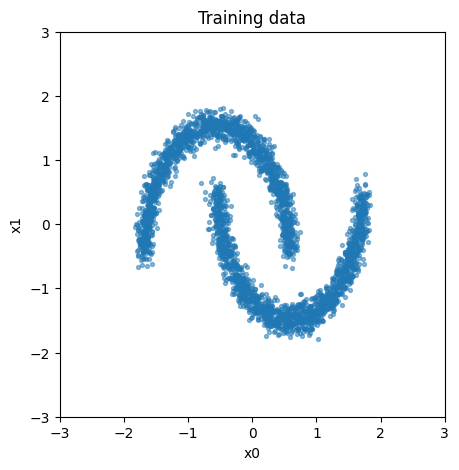

In [5]:
plot_points(x, "Training data")
plt.show()

The target distribution is visibly non-Gaussian: it has two curved high-density regions separated by a low-density gap.

## Creating the Data Loader

The flow is trained by maximum likelihood. Each batch contains only the coordinates of the data points. There are no labels.

In [6]:
import torch

x_tensor = torch.tensor(x, dtype=torch.float32)

train_dataset = torch.utils.data.TensorDataset(x_tensor)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
)

## Fitting a Gaussian Baseline

Before implementing the normalizing flow, fit a single Gaussian distribution to the data. 
A Gaussian is the simplest probabilistic model for continuous data and is completely described by its mean and covariance. Because its contours are always elliptical, it cannot capture the curved structure of the two-moons distribution.
This makes it a useful baseline: both models start from the same Gaussian distribution, but the normalizing flow additionally learns an invertible transformation that can deform the Gaussian into a much more complex distribution.

Fit a Gaussian distribution to the data by estimating its mean and covariance, which completely define a multivariate Gaussian distribution ...

In [7]:
mean_gt = x.mean(axis=0)
cov_gt = np.cov(x.T)

... generate new samples from the fitted Gaussian distribution ...

In [8]:
baseline_samples = np.random.multivariate_normal(
    mean_gt,
    cov_gt,
    size=3000,
).astype("float32")

... and ompare the training data with samples drawn from the fitted Gaussian.

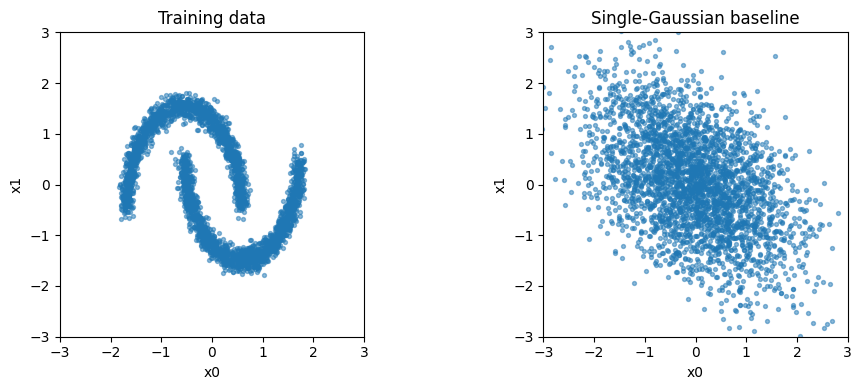

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_points(x, "Training data", ax=axes[0])
plot_points(baseline_samples, "Single-Gaussian baseline", ax=axes[1])
plt.tight_layout()
plt.show()

The Gaussian baseline produces an elliptical cloud. It gets the approximate location and spread of the data right, but it fills the empty region between the two moons. The normalizing flow should do better by learning a nonlinear transformation.

## Implementing an Affine Coupling Layer

You'll now implement the central RealNVP building block. The layer receives a binary mask that decides which coordinate remains fixed and which coordinate is transformed.

The scale network predicts $s(x)$ and the translation network predicts $t(x)$. The scale is passed through a bounded `tanh` nonlinearity to keep early training stable.

In [10]:
import deeplay as dl


class AffineCouplingLayer(dl.DeeplayModule):
    """Affine coupling layer for a two-dimensional RealNVP flow."""

    def __init__(self, mask, hidden_features=64):
        """Intialize the affine coupling layer."""

        super().__init__()

        self.mask = torch.tensor(mask, dtype=torch.float32)

        net = dl.MultiLayerPerceptron(
            in_features=2,
            hidden_features=[hidden_features, hidden_features],
            out_features=2,
        )
        net[..., "activation#:-1"].configure(torch.nn.Tanh)

        self.scale_net = net.create()
        self.translate_net = net.create()

    def forward(self, x):
        """Map data-space variables toward latent-space variables."""

        x_masked = x * self.mask  # (1)

        scale = self.scale_net(x_masked)  # (2)
        scale = 0.8 * torch.tanh(scale) * (1 - self.mask)  # (3)

        translation = self.translate_net(x_masked) * (1 - self.mask)  # (4)

        z = x_masked + (1 - self.mask) * (x * torch.exp(scale) + translation)

        log_det = scale.sum(dim=1)

        return z, log_det

    def inverse(self, z):
        """Map latent-space variables back to data-space variables."""

        z_masked = z * self.mask

        scale = self.scale_net(z_masked)
        scale = 0.8 * torch.tanh(scale) * (1 - self.mask)

        translation = self.translate_net(z_masked) * (1 - self.mask)

        x = (
            z_masked
            + (1 - self.mask) * ((z - translation) * torch.exp(-scale))
        )

        return x

The `AffineCouplingLayer` class implements a single affine coupling layer. It contains two small multilayer perceptrons, `scale_net` and `translate_net`, which learn the scaling and translation functions introduced earlier. Both networks have the same architecture, but they learn different transformations.

The `.forward()` method maps points from the data space to the latent space:

1. The first operation,
   ```python
   x_masked = x * self.mask
   ```
   applies the binary mask. One coordinate is kept unchanged, while the other is set to zero. The unchanged coordinate will be used to determine how the other coordinate should be transformed.

2. The masked input is passed through the `scale_net`, which predicts the   scaling factor for the transformed coordinate. Since only the unmasked coordinate should be modified, the output is multiplied by `(1 - self.mask)`. The scaling factor is also passed through a `tanh()` function and multiplied by `0.8` to keep it within a reasonable range, which improves numerical stability during training.

3. The masked input is also passed through the `translate_net`, which predicts the translation to apply to the transformed coordinate. Again, the mask ensures that only the selected coordinate is modified.

4. Finally, the affine transformation is applied. The masked coordinate is copied directly to the output, while the remaining coordinate is scaled and translated according to the outputs of the two neural networks. At the same time, the logarithm of the Jacobian determinant is computed by summing the scaling factors. Because the Jacobian of an affine coupling layer is triangular, this computation is particularly simple.

The `.inverse()` method performs exactly the opposite transformation. Starting from a point in the latent space, it first applies the same mask and recomputes the scale and translation from the unchanged coordinate. It then analytically reverses the affine transformation,
$$
x = (z - t)\exp(-s),
$$
recovering the original data point. No optimization or numerical inversion is required: the inverse follows directly from the affine transformation, making the mapping exact and efficient.


### Checking Invertibility

Before stacking many layers, test one coupling layer. Applying the forward map and then the inverse map should recover the original points up to numerical precision.

In [11]:
test_layer = AffineCouplingLayer(mask=[1, 0])

test_x = torch.randn(5, 2)
test_z, test_log_det = test_layer(test_x)
test_x_reconstructed = test_layer.inverse(test_z)

max_reconstruction_error = (test_x - test_x_reconstructed).abs().max()

print(
    f"Maximum test_x: {test_x.abs().max()}\n"
    f"Maximum test_x_reconstructed: {test_x_reconstructed.abs().max()}\n"
    f"Maximum reconstruction error: {max_reconstruction_error}"
)

Maximum test_x: 2.2362828254699707
Maximum test_x_reconstructed: 2.2362828254699707
Maximum reconstruction error: 2.9802322387695312e-08


The reconstruction error should be very small. This is a useful sanity check: if the inverse does not recover the input, the flow cannot be used reliably for density evaluation or sampling.

## Stacking Coupling Layers into a Flow

A full normalizing flow is a sequence of invertible layers. The forward pass maps data points $x$ to latent points $z$ and accumulates the log determinant of all layers. The inverse pass maps Gaussian latent samples back into data space.

In [12]:
import math


class RealNVP(dl.DeeplayModule):
    """RealNVP normalizing flow for two-dimensional data."""

    def __init__(self, num_layers=8, hidden_features=64):
        """Initialize RealNVP normalizing flow."""

        super().__init__()

        masks = []
        for layer_idx in range(num_layers):
            if layer_idx % 2 == 0:
                masks.append([1, 0])
            else:
                masks.append([0, 1])

        self.layers = torch.nn.ModuleList(
            [AffineCouplingLayer(mask, hidden_features) for mask in masks]
        )

    def forward(self, x):
        """Map data samples to latent samples and compute log determinant."""

        z = x
        log_det_total = torch.zeros(x.shape[0])

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_total = log_det_total + log_det

        return z, log_det_total

    def inverse(self, z):
        """Map latent samples to data samples."""

        x = z

        for layer in reversed(self.layers):
            x = layer.inverse(x)

        return x

    def log_prob(self, x):
        """Calculate exact log probability under the flow."""

        z, log_det = self.forward(x)

        log_prob_z = -0.5 * (z.pow(2) + math.log(2 * math.pi)).sum(dim=1)

        return log_prob_z + log_det

    def sample(self, num_samples):
        """Generate samples by transforming Gaussian noise."""

        z = torch.randn(num_samples, 2)

        return self.inverse(z)

## Inspecting the Untrained Flow

Before training, the flow is randomly initialized. Its samples should still look roughly Gaussian or randomly distorted. Training will adjust the coupling layers so that the inverse transformation maps Gaussian samples into the two-moons distribution.

In [13]:
model = RealNVP(num_layers=8, hidden_features=64)

with torch.no_grad():
    untrained_samples = model.sample(3000).numpy()

Now plot it.

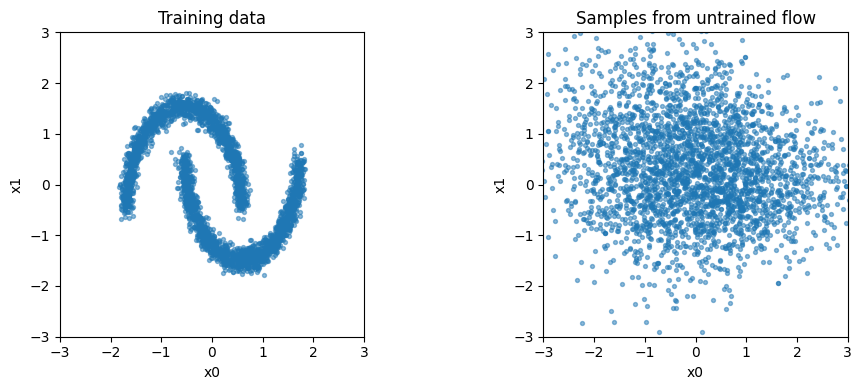

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_points(x, "Training data", ax=axes[0])
plot_points(untrained_samples, "Samples from untrained flow", ax=axes[1])
plt.tight_layout()
plt.show()

The untrained model is not expected to match the data. This plot defines the starting point of the learning process.

## Training by Maximum Likelihood

For each batch, the model maps the data points to latent points and computes their exact log probability. The optimized loss is the negative log-likelihood:
$$
\mathcal{L}
=
-\frac{1}{N}\sum_{i=1}^{N}\log p_X(x_i)
$$
Lower values mean that the model assigns higher probability density to the observed data.

During training, you'll store generated samples at a few epochs. These snapshots will let you inspect how the learned distribution evolves.

In [15]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 1500
snapshot_epochs = {0, 2, 5, 10, 25, 50, 200, 600, 1500}

loss_history = []
sample_snapshots = {}
latent_snapshots = {}

for epoch in range(num_epochs + 1):
    model.train()
    epoch_loss = 0.0
    num_seen = 0

    for (x_batch,) in train_loader:

        loss = -model.log_prob(x_batch).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_batch.shape[0]
        num_seen += x_batch.shape[0]

    epoch_loss = epoch_loss / num_seen
    loss_history.append(epoch_loss)

    if epoch in snapshot_epochs:
        model.eval()
        with torch.no_grad():
            sample_snapshots[epoch] = model.sample(3000).numpy()
            z_snapshot, _ = model(x_tensor)
            latent_snapshots[epoch] = z_snapshot.numpy()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | negative log-likelihood = {epoch_loss:.4f}")

Epoch    0 | negative log-likelihood = 2.7604
Epoch   50 | negative log-likelihood = 1.7101
Epoch  100 | negative log-likelihood = 1.5577
Epoch  150 | negative log-likelihood = 1.4520
Epoch  200 | negative log-likelihood = 1.4485
Epoch  250 | negative log-likelihood = 1.4126
Epoch  300 | negative log-likelihood = 1.4059
Epoch  350 | negative log-likelihood = 1.3751
Epoch  400 | negative log-likelihood = 1.4055
Epoch  450 | negative log-likelihood = 1.3631
Epoch  500 | negative log-likelihood = 1.3431
Epoch  550 | negative log-likelihood = 1.3574
Epoch  600 | negative log-likelihood = 1.3577
Epoch  650 | negative log-likelihood = 1.3745
Epoch  700 | negative log-likelihood = 1.3431
Epoch  750 | negative log-likelihood = 1.3476
Epoch  800 | negative log-likelihood = 1.3415
Epoch  850 | negative log-likelihood = 1.3335
Epoch  900 | negative log-likelihood = 1.3380
Epoch  950 | negative log-likelihood = 1.3255
Epoch 1000 | negative log-likelihood = 1.3315
Epoch 1050 | negative log-likeliho

Unlike losses such as the mean squared error, the negative log-likelihood is not expected to approach zero. Its minimum depends on the complexity of the data distribution and the expressive power of the model. As training progresses, the NLL decreases until the model reaches the best approximation of the data distribution that it can represent.

## Plotting the Training Curve

The negative log-likelihood should generally decrease, although it may not be perfectly monotonic because training uses mini-batches and stochastic optimization.

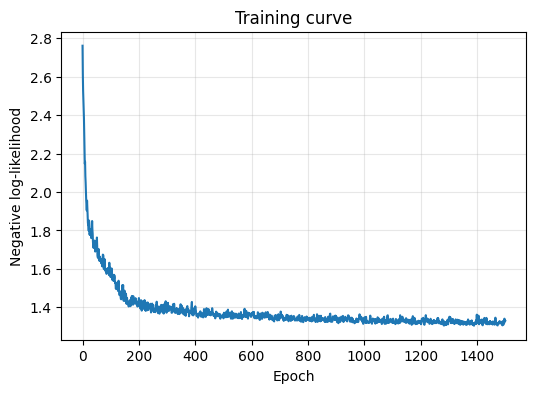

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Negative log-likelihood")
plt.title("Training curve")
plt.grid(True, alpha=0.3)
plt.show()

## Comparing Samples Before and After Training

The most direct way to inspect the learned generative model is to sample from it. The trained flow should transform Gaussian latent samples into points that concentrate along the two moons.

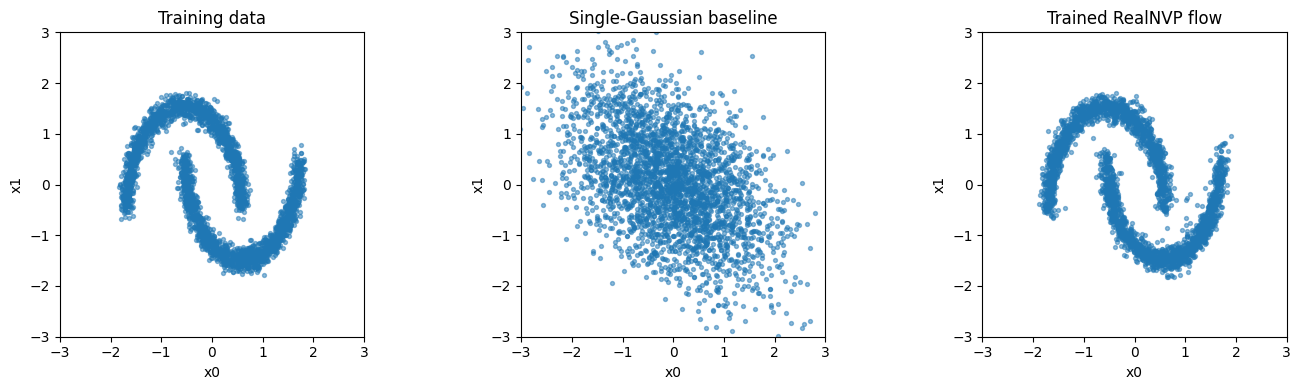

In [17]:
model.eval()
with torch.no_grad():
    trained_samples = model.sample(3000).numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_points(x, "Training data", ax=axes[0])
plot_points(baseline_samples, "Single-Gaussian baseline", ax=axes[1])
plot_points(trained_samples, "Trained RealNVP flow", ax=axes[2])
plt.tight_layout()
plt.show()

The baseline captures only the overall elliptical spread. The flow should better capture the curved high-density regions and should place fewer samples in the empty region between the moons.

## Visualizing the Learning Process

The snapshots below show generated samples from the inverse flow during training. Early samples are poorly organized. As training progresses, the model gradually bends the Gaussian into the target distribution.

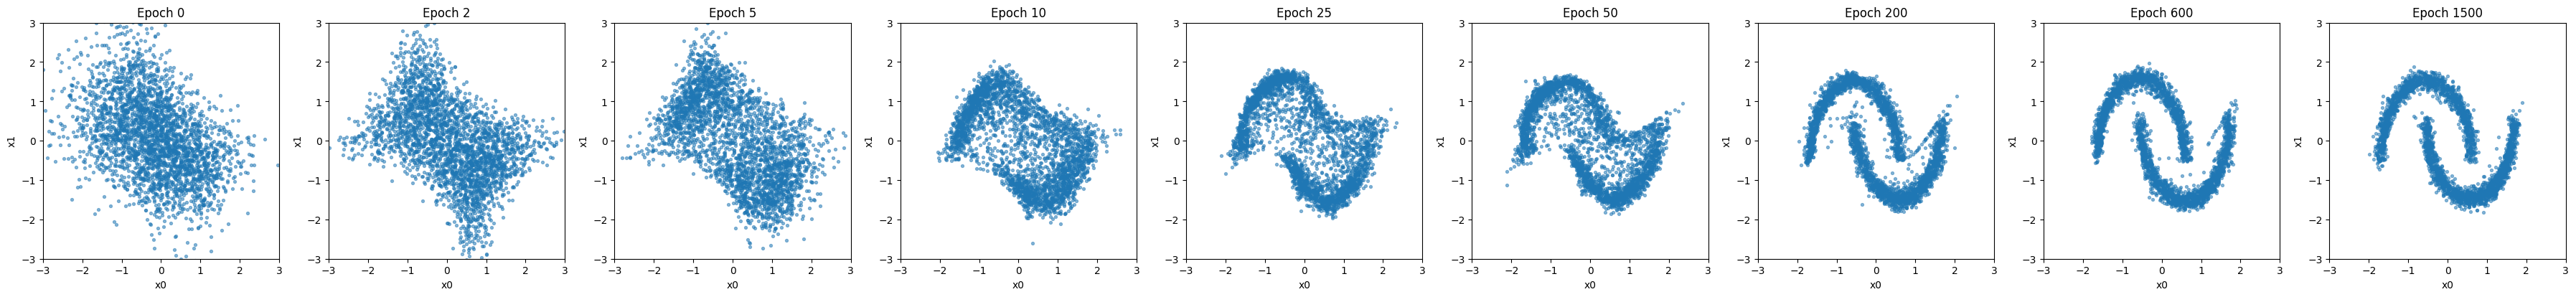

In [18]:
fig, axes = plt.subplots(
    1, len(sample_snapshots), figsize=(4 * len(sample_snapshots), 4)
)

for ax, epoch in zip(axes, sorted(sample_snapshots)):
    plot_points(sample_snapshots[epoch], f"Epoch {epoch}", ax=ax)

plt.tight_layout()
plt.show()

## Inspecting the Latent Space

A trained flow should also map the data distribution back to something close to a standard Gaussian. This is the forward direction of the model:
$$
x \rightarrow z
$$
If training worked, the two curved moons should become a compact, approximately Gaussian cloud in latent space.

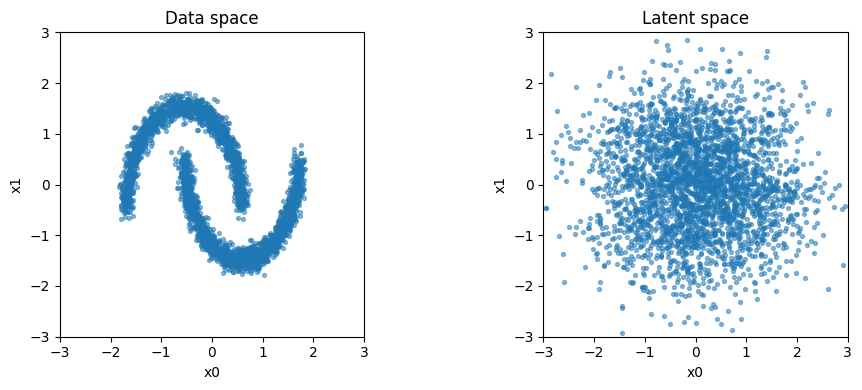

Latent mean: [ 0.03099625 -0.0012397 ]
Latent standard deviation: [1.003658   0.95727926]


In [19]:
with torch.no_grad():
    z_p, _ = model(x_tensor)
    z_p = z_p.numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_points(x, "Data space", ax=axes[0])
plot_points(z_p, "Latent space", ax=axes[1])
plt.tight_layout()
plt.show()

print("Latent mean:", z_p.mean(axis=0))
print("Latent standard deviation:", z_p.std(axis=0))

The latent points do not need to form a perfect Gaussian, especially for a small model trained briefly. Still, they should be much less curved and more compact than the original data distribution.

## Evaluating Against the Gaussian Baseline

Because normalizing flows provide exact likelihoods, you can compare the average negative log-likelihood of the trained flow with that of the fitted Gaussian baseline.

This comparison is not the only way to evaluate generative models, but it is a natural one here because likelihood is the quantity the flow optimizes directly.

In [20]:
def gaussian_log_prob(points, mean, cov):
    """Calculate log probability under a fitted multivariate Gaussian."""
    dim = points.shape[1]
    centered = points - mean
    inv_cov = np.linalg.inv(cov)
    log_det_cov = np.linalg.slogdet(cov)[1]

    quadratic = np.sum(centered @ inv_cov * centered, axis=1)
    return -0.5 * (dim * np.log(2 * np.pi) + log_det_cov + quadratic)


baseline_nll = -gaussian_log_prob(x, mean_gt, cov_gt).mean()

model.eval()
with torch.no_grad():
    flow_nll = -model.log_prob(x_tensor).mean().item()

print(f"Single-Gaussian baseline NLL: {baseline_nll:.4f}")
print(f"RealNVP flow NLL:             {flow_nll:.4f}")

Single-Gaussian baseline NLL: 2.7216
RealNVP flow NLL:             1.3137


The flow should typically achieve a lower negative log-likelihood than the single Gaussian baseline. This means that it assigns higher probability density to the observed data.

Do not overinterpret small numerical differences between runs. The model is stochastic, and short training runs may vary. The qualitative comparison of samples and latent-space structure is equally important in this educational example.

## Visualizing the Learned Density

Since the data are two-dimensional, you can evaluate the learned log probability on a grid and plot it as a density map. This gives a more complete picture than samples alone.

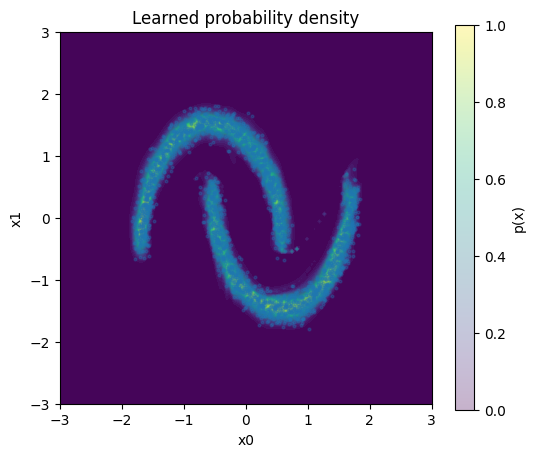

In [21]:
def evaluate_log_prob_on_grid(model, xlim=(-3, 3), ylim=(-3, 3), num_points=150):
    """Evaluate flow log probability on a two-dimensional grid."""
    x0 = np.linspace(xlim[0], xlim[1], num_points)
    x1 = np.linspace(ylim[0], ylim[1], num_points)
    grid_x0, grid_x1 = np.meshgrid(x0, x1)
    grid = np.stack([grid_x0.ravel(), grid_x1.ravel()], axis=1).astype("float32")

    grid_tensor = torch.tensor(grid)

    model.eval()
    with torch.no_grad():
        log_prob = model.log_prob(grid_tensor).numpy()

    log_prob = log_prob.reshape(num_points, num_points)
    return x0, x1, log_prob


x0_grid, x1_grid, log_prob_grid = evaluate_log_prob_on_grid(model)

plt.figure(figsize=(6, 5))
plt.contourf(x0_grid, x1_grid, np.exp(log_prob_grid), levels=50)
plt.scatter(x[:, 0], x[:, 1], s=4, alpha=0.3)
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Learned probability density")
plt.colorbar(label="p(x)")
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

The high-density regions should align with the two moons. This plot is often the clearest demonstration that a normalizing flow is not merely producing plausible samples; it is learning a probability density over the data space.

## Testing the Inverse Consistency of the Full Flow

As a final sanity check, apply the full flow forward and then backward. The reconstructed points should match the original input points up to small numerical errors.

In [22]:
model.eval()
with torch.no_grad():
    x_test = x_tensor[:10]
    z_test, _ = model(x_test)
    x_reconstructed = model.inverse(z_test)

reconstruction_error = (x_test - x_reconstructed).abs().max()

print(
    f"Maximum x_test: {x_test.abs().max()}\n"
    f"Maximum x_reconstructed: {x_reconstructed.abs().max()}\n"
    f"Maximum reconstruction error: {reconstruction_error}"
)

Maximum x_test: 1.6936451196670532
Maximum x_reconstructed: 1.6936450004577637
Maximum reconstruction error: 3.5762786865234375e-07


This near-zero reconstruction error is specific to invertible models. A standard encoder-decoder may reconstruct inputs approximately, but a normalizing flow is designed so that the inverse transformation is exact up to floating-point precision.

## Limitations

Normalizing flows are elegant, but they also have important limitations.

First, invertibility restricts the architecture. You cannot use arbitrary neural-network layers if they destroy information or make the Jacobian determinant intractable.

Second, the model dimension is fixed. The latent variable and the data must have the same dimensionality. This differs from autoencoders, where the latent space can be lower-dimensional.

Third, likelihood and sample quality do not always agree perfectly, especially in high-dimensional data such as natural images.

Fourth, simple coupling-layer flows may struggle with very complex distributions unless many layers, stronger transformations, or more advanced architectures are used.

Finally, while flows can sample faster than diffusion models, they may be less flexible than state-of-the-art diffusion models for high-resolution image generation.

## Exercises

In this notebook, you learned how a normalizing flow transforms a simple Gaussian distribution into a more complex data distribution using a sequence of invertible neural-network layers. The following exercises will help you explore how the architecture, the data, and the training process affect the learned transformation, before suggesting several natural extensions of the method.

### Exploring the Current Example

1. **Change the number of coupling layers**

   Train the model with `num_layers=2`, `4`, `8`, and `12`. How does the complexity of the learned distribution change? Is there a point beyond which adding more layers produces only small improvements?

2. **Modify the size of the neural networks**

   Change `hidden_features` to smaller and larger values. How does the capacity of the scale and translation networks affect the quality of the learned transformation?

3. **Change the amount of noise in the dataset**

   Increase and decrease the noise when generating the two-moons dataset. How does this affect the learned probability distribution and the latent-space representation?

4. **Study the training process**

   Train the model for different numbers of epochs. At what point does the generated distribution begin to resemble the two moons? How do the generated samples and latent-space representation evolve during training?

### Exploring Different Data Distributions

5. **Replace the two moons**

   Train the normalizing flow on a different two-dimensional dataset, such as concentric rings, a spiral, or a mixture of Gaussian clusters. Which distributions are easier or harder to learn?

6. **Compare with the Gaussian baseline**

   Fit a single Gaussian to each new dataset and compare it with the learned normalizing flow. For which datasets does the Gaussian provide a reasonable approximation, and where does it fail?

7. **Inspect the latent space**

   For each dataset, visualize the latent representation learned by the flow. Does every distribution become approximately Gaussian? Are some datasets more difficult to "untwist" than others?

### Going Further

8. **Add permutations between coupling layers**

   Instead of simply alternating the mask, insert a permutation (or rotation) of the variables between successive coupling layers. Does this improve the learned transformation?

9. **Implement a conditional normalizing flow**

   Modify the coupling layers so that the scale and translation networks also receive a class label as input. How could this allow the model to generate samples from different classes?

10. **Scale up to higher-dimensional data**

    Apply the same ideas to a simple image dataset. What changes are needed in the architecture? How does the computational cost scale with the dimensionality of the data? Which properties of RealNVP make this extension possible?

## Further Readings

Dinh, L., Sohl-Dickstein, J., & Bengio, S. (2017). Density estimation using Real NVP. *International Conference on Learning Representations (ICLR).*

Rezende, D. J., & Mohamed, S. (2015). Variational inference with normalizing flows. In F. Bach & D. Blei (Eds.), *Proceedings of the 32nd International Conference on Machine Learning* (Vol. 37, pp. 1530–1538). PMLR.

Papamakarios, G., Nalisnick, E., Rezende, D. J., Mohamed, S., & Lakshminarayanan, B. (2021). Normalizing flows for probabilistic modeling and inference. *Journal of Machine Learning Research*, 22, 1–64.